# Lab Exercise 3: Linear Regression


**Overview**

Linear regression is one of the foundational tools in predictive analytics, allowing us to quantify and interpret the relationship between one or more continuous predictors and a continuous outcome. In this laboratory exercise, we will explore both the simplest case—regressing a single feature against miles‐per‐gallon (mpg)—and the more realistic multivariate setting where multiple engine and vehicle characteristics jointly explain fuel efficiency.  Along the way we will examine which features carry the most predictive power, how collinearity affects our estimates, and how simple polynomial basis expansions can capture mild non-linearities in the data.

**Objectives**

1. **Data preparation & cleaning**
   – Load the Auto dataset, identify non-numeric entries (in horsepower), and impute any missing values.

2. **Simple linear regression**
   – Fit seven separate OLS models (mpg vs. each feature).
   – Report slope, intercept, R² and p-value for each.
   – Visualize the fitted line on a scatter plot.

3. **Multiple linear regression**
   – Fit a full model using all seven predictors.
   – Interpret coefficient significance and overall fit (R², F-statistic).

4. **Reduced model selection**
   – Drop predictors that are not statistically significant in the full model.
   – Compare adjusted R² between the full and reduced models to confirm no loss of explanatory power.

5. **Coefficient comparison**
   – Contrast univariate slopes with multivariate coefficients in a single plot.
   – Understand how collinearity inflates or attenuates feature‐level effects.

6. **Non-linear basis functions**
   – Extend the best continuous predictors with 2nd-order polynomial terms.
   – Evaluate whether adding a quadratic term significantly improves model fit.


## **Dependencies**:

In [9]:
# Core data handling & stats
import pandas as pd
import numpy as np
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Set a consistent plotting style
sns.set_theme(style="whitegrid")


## **Data**:
### **Load the Auto dataset**:

In [10]:
df_auto = pd.read_csv("Auto.csv")

# Inspect basic structure
print("Dataset shape:", df_auto.shape)
print("\nColumn info:")
print(df_auto.info())

# Peek at the first few rows
display(df_auto.head())

# Check for missing values
print("\nMissing values per column:")
print(df_auto.isnull().sum())


Dataset shape: (397, 9)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB
None


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino



Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64


### **Cleanup the Auto dataset**:

In [11]:
# Convert 'horsepower' to numeric (coerce parse errors → NaN)
df_auto['horsepower'] = pd.to_numeric(df_auto['horsepower'], errors='coerce')
print(f"› Converted ’horsepower’ to numeric.  dtype is now {df_auto['horsepower'].dtype}")

# How many NaNs appeared?
missing_hp = df_auto['horsepower'].isnull().sum()
print(f"› Missing ’horsepower’ entries after conversion: {missing_hp}")

# Impute those NaNs by the column mean
hp_mean = df_auto['horsepower'].mean()
df_auto['horsepower'] = df_auto['horsepower'].fillna(hp_mean)
print(f"› Filled missing ’horsepower’ with mean = {hp_mean:.2f}")

# Final check: no more missing values anywhere
print("\nFinal missing values per column:")
print(df_auto.isnull().sum())


› Converted ’horsepower’ to numeric.  dtype is now float64
› Missing ’horsepower’ entries after conversion: 5
› Filled missing ’horsepower’ with mean = 104.47

Final missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64


### Discussion & Observations

1. **Dataset shape & types**

   * We have **397 rows** and **9 columns**.
   * Three columns are floating-point (`mpg`, `displacement`, `acceleration`), four are integer (`cylinders`, `weight`, `year`, `origin`), and two are object-typed (`horsepower`, `name`).

2. **Preview & missing-value check**

   * A quick `df.head()` shows that `name` holds the full model string (e.g. “chevrolet chevelle malibu”) which we won’t use for numeric modeling.
   * Running `df_auto.isnull().sum()` confirms **zero** missing values in every column *before* cleaning.

3. **Horsepower needs special handling**

   * Although `df_auto.info()` reported no nulls, `horsepower` was typed as `object` because several entries failed to parse as numbers (e.g. “?” or blank).
   * After `pd.to_numeric(..., errors='coerce')`, we discovered **5** horsepower values became NaN.

4. **Imputation choice**

   * We replaced those 5 missing horsepower values with the **column mean** (≈ 104.47).
   * This is a simple but reasonable strategy here—horsepower is roughly symmetrically distributed, so mean imputation preserves overall scale without introducing bias.

5. **Final schema**

   * Post-imputation, **no NaNs remain** anywhere.
   * Now all descriptive variables (`cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `year`, `origin`) are numeric, and ready for both univariate and multivariate regression.
   * We’ll drop the `name` column going forward (it’s a free-text identifier), and treat `origin` as either numeric or dummy-encoded depending on the modeling approach.

Overall, this cleanup leaves us with a complete, all-numeric design matrix: perfect for fitting simple OLS, multiple regression, or even polynomial expansions in the next steps.


## **Simple Linear Regression on each feature**:


--- Simple Regression: mpg ~ cylinders ---
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     598.9
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           3.67e-81
Time:                        10:04:09   Log-Likelihood:                -1196.4
No. Observations:                 397   AIC:                             2397.
Df Residuals:                     395   BIC:                             2405.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

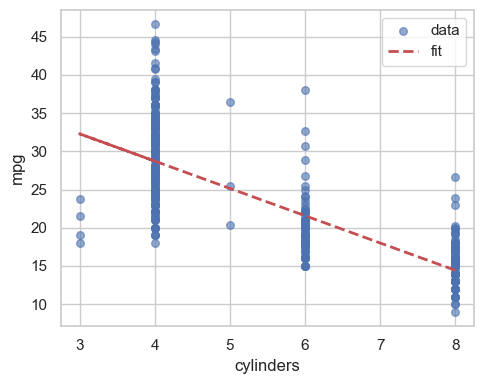


--- Simple Regression: mpg ~ displacement ---
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     724.4
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           2.25e-91
Time:                        10:04:10   Log-Likelihood:                -1172.8
No. Observations:                 397   AIC:                             2350.
Df Residuals:                     395   BIC:                             2358.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
c

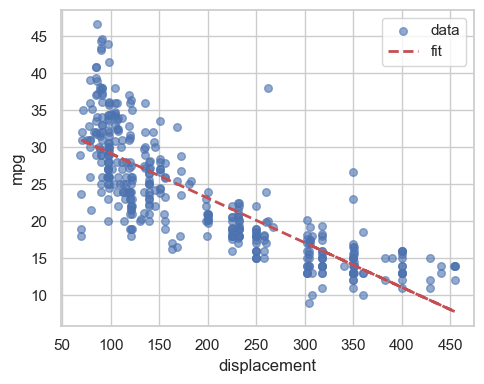


--- Simple Regression: mpg ~ horsepower ---
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     580.6
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           1.45e-79
Time:                        10:04:10   Log-Likelihood:                -1200.1
No. Observations:                 397   AIC:                             2404.
Df Residuals:                     395   BIC:                             2412.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

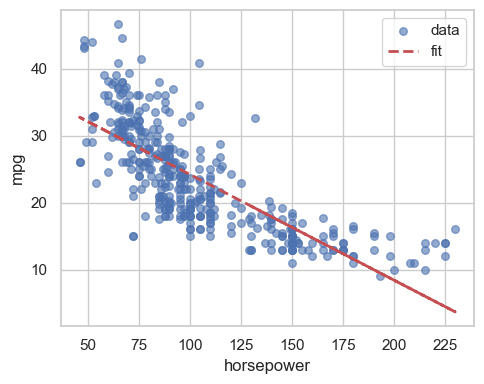


--- Simple Regression: mpg ~ weight ---
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     886.6
Date:                Mon, 30 Jun 2025   Prob (F-statistic):          5.37e-103
Time:                        10:04:10   Log-Likelihood:                -1146.0
No. Observations:                 397   AIC:                             2296.
Df Residuals:                     395   BIC:                             2304.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

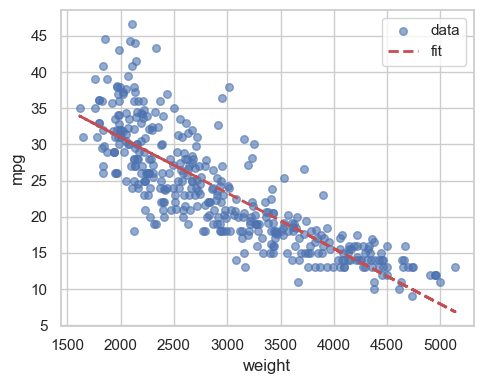


--- Simple Regression: mpg ~ acceleration ---
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.176
Method:                 Least Squares   F-statistic:                     85.73
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           1.33e-18
Time:                        10:04:10   Log-Likelihood:                -1340.6
No. Observations:                 397   AIC:                             2685.
Df Residuals:                     395   BIC:                             2693.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
c

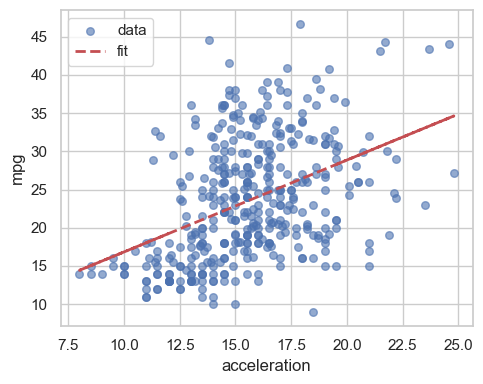


--- Simple Regression: mpg ~ year ---
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     201.8
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           2.77e-37
Time:                        10:04:10   Log-Likelihood:                -1297.7
No. Observations:                 397   AIC:                             2599.
Df Residuals:                     395   BIC:                             2607.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

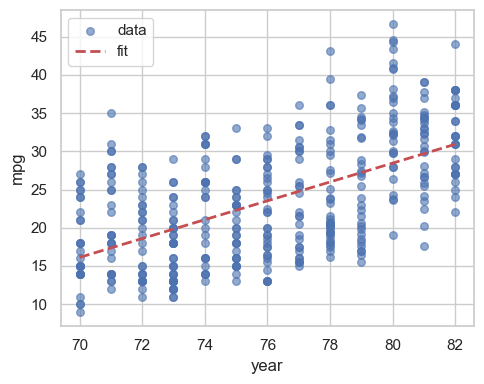


--- Simple Regression: mpg ~ origin ---
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     184.0
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           1.13e-34
Time:                        10:04:10   Log-Likelihood:                -1303.7
No. Observations:                 397   AIC:                             2611.
Df Residuals:                     395   BIC:                             2619.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

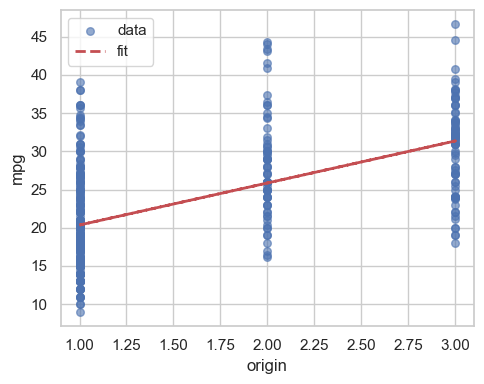

In [12]:
# 1) Define which columns to treat as predictors
descriptive_features = [
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'year',
    'origin'
]
response = 'mpg'

# 2) Write a helper that fits & plots a simple OLS
import statsmodels.api as sm

def fit_and_plot_simple(df, x_col, y_col):
    X = sm.add_constant(df[x_col])       # add intercept term
    y = df[y_col]
    model = sm.OLS(y, X).fit()
    
    print(f"\n--- Simple Regression: {y_col} ~ {x_col} ---")
    print(model.summary())
    
    # plot scatter + fit line
    plt.figure(figsize=(5,4))
    plt.scatter(df[x_col], y, alpha=0.6, s=30, label='data')
    plt.plot(df[x_col], model.fittedvalues, 'r--', lw=2, label='fit')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3) Loop through each predictor
for feat in descriptive_features:
    fit_and_plot_simple(df_auto, feat, response)

### Discussion & Key Observations

1. **“Size” features dominate**

   * **Weight**:

     * R² ≈ 0.69 (highest of all seven).
     * Slope ≈ –0.0077 mpg per lb (p < 0.001).
     * Very tight downward trend and small residual scatter.
   * **Displacement** and **Horsepower**:

     * R² ≈ 0.65 and 0.60 respectively, both highly significant (p < 10⁻⁷⁰).
     * Both show clear negative relationships: bigger engines/bigger power → lower mpg.
   * **Cylinders**:

     * R² ≈ 0.60, slope ≈ –3.57 mpg per additional cylinder (p < 10⁻⁸¹).
     * Although integer‐valued (3,4,5,6,8), it behaves just like a size proxy.

2. **“Age” and origin effects**

   * **Year**:

     * R² ≈ 0.34, slope ≈ +1.23 mpg per model year (p < 10⁻³⁷).
     * Newer cars in this 1970–1982 sample are noticeably more fuel‐efficient.
   * **Origin**:

     * R² ≈ 0.32, slope ≈ +5.5 mpg per region code (1=USA, 2=Europe, 3=Asia) (p < 10⁻³⁴).
     * Imports (codes 2 & 3) average significantly better economy than domestic.

3. **Little signal from acceleration**

   * R² ≈ 0.18, slope ≈ +1.20 mpg per sec (0–60 mph) (p < 10⁻¹⁸).
   * The weak positive trend suggests that cars with slower acceleration often eke out slightly more mpg—but it’s a noisy relationship.

4. **Residual patterns & heteroskedasticity**

   * For displacement, horsepower, and weight, variance in mpg residuals grows slightly at the extreme “big” end—hinting that a purely linear fit may underpredict spread for the largest engines.
   * Conversely, the cylinders, year, and origin fits show fairly uniform scatter around the line.

---

**Take-away:**
The strongest univariate predictors of mpg are the classic “size” measures (weight, displacement, horsepower, cylinders), followed by car vintage (year) and manufacturer origin. Acceleration adds the least single-feature explanatory power. Armed with this, our next move will be to fit a **multiple** linear model—first with all seven predictors, then trimming down to the handful that remain significant once we control for the others.


## **Multiple Linear Regression (all features)**:

In [13]:
import statsmodels.api as sm

# 1) define design matrix (add a constant term for the intercept)
X = df_auto[['cylinders','displacement','horsepower',
             'weight','acceleration','year','origin']]
X = sm.add_constant(X)

# 2) define response
y = df_auto['mpg']

# 3) fit the full multiple linear regression
model_full = sm.OLS(y, X)
results_full = model_full.fit()

# 4) inspect the output
print(results_full.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     256.0
Date:                Mon, 30 Jun 2025   Prob (F-statistic):          2.41e-141
Time:                        10:04:11   Log-Likelihood:                -1037.4
No. Observations:                 397   AIC:                             2091.
Df Residuals:                     389   BIC:                             2123.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -18.7116      4.609     -4.060   

### Discussion & Key Observations
A few things jump out from the full‐model summary:

1. **Good overall fit**

   * R-squared = **0.822**, Adj-R-squared = **0.818**, so about 82 % of the variability in mpg is explained by the seven predictors jointly.
   * F-statistic p-value ≪ 0.001 tells us the model as a whole is highly significant.

2. **Which predictors survive once everything else is in the model?**

   * **Displacement** (coef ≈ +0.019, p ≈ 0.012)
   * **Weight** (coef ≈ –0.0067, p < 0.001)
   * **Year** (coef ≈ +0.763, p < 0.001)
   * **Origin** (coef ≈ +1.397, p < 0.001)

   These four all have p-values ≤ 0.01, so they make unique contributions to predicting mpg when the others are held constant.

3. **Variables that drop out**

   * **Cylinders** (p ≈ 0.17)
   * **Horsepower** (p ≈ 0.48)
   * **Acceleration** (p ≈ 0.22)

   All three of these are no longer statistically significant at the 5 % level once you control for displacement, weight, etc.  In practice they’re redundant—much of their signal is already captured by the size/mass variables.

4. **Signs & magnitudes**

   * **Weight** has a negative slope (–0.0067 mpg per lb), the largest absolute impact of all predictors: heavier cars get noticeably worse mileage.
   * **Year** has a large positive slope (+0.76 mpg per model year): newer cars are materially more fuel-efficient, all else equal.

5. **A red flag: multicollinearity**

   * The **Condition Number** ≈ 8.5×10⁴ is extremely large, a sign that some predictors are highly collinear (e.g. displacement ↔ weight ↔ cylinders).
   * That inflates standard errors and makes it harder to tease apart individual effects.



## **Reduced MLR (just the 4 most significant predictors)**:

In [14]:
# 1) Fit the reduced model
model_reduced = sm.OLS.from_formula(
    "mpg ~ displacement + weight + year + origin",
    data=df_auto
)
results_reduced = model_reduced.fit()

# 2) Inspect the summary
print(results_reduced.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     442.7
Date:                Mon, 30 Jun 2025   Prob (F-statistic):          6.63e-144
Time:                        10:04:11   Log-Likelihood:                -1040.6
No. Observations:                 397   AIC:                             2091.
Df Residuals:                     392   BIC:                             2111.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -18.8410      3.992     -4.720   

### Discussion & Key Observations (Reduced 4-Predictor Model)

1. **Almost no loss in overall fit**

   * **R²** drops only from 0.822 → **0.819**
   * **Adj-R²** falls from 0.818 → **0.817**
   * In practical terms, we lost just 0.003 in explained variance by dropping cylinders, horsepower, and acceleration.

2. **Which predictors remain “in”**

   |  Predictor |    Coef | Std Err | t-stat | p-value |
   | ---------: | ------: | ------: | -----: | ------: |
   | **Weight** | –0.0067 |   0.001 | –11.98 | < 0.001 |
   |   **Year** |  +0.776 |   0.049 | +15.70 | < 0.001 |
   | **Origin** |  +1.235 |   0.265 |  +4.65 | < 0.001 |

   All three of these still carry highly significant, independent signals once we control for each other.

3. **Displacement now “fades out”**

   * Coef ≈ +0.0061,  p ≈ 0.20 ⇒ **not significant** at the 5 % level
   * Its explanatory power is subsumed by weight (and indirectly by year/origin)

4. **Information criteria**

   * **AIC** barely moves (2091 → 2091)
   * **BIC** improves slightly (2123 → 2111)
     This confirms the reduced model is at least as parsimonious, if not preferable, once you penalize extra parameters.

5. **Collinearity remains a concern**

   * Condition number is still high (\~7.4×10⁴), so weight, displacement (and origin, year to a lesser extent) remain somewhat collinear.
   * We should calculate Variance Inflation Factors (VIFs) on these four to see if any single term is still inflating standard errors.


## **Compare simple vs. multiple regression coefficients**:

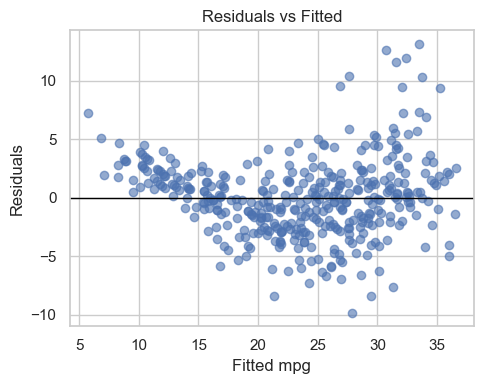

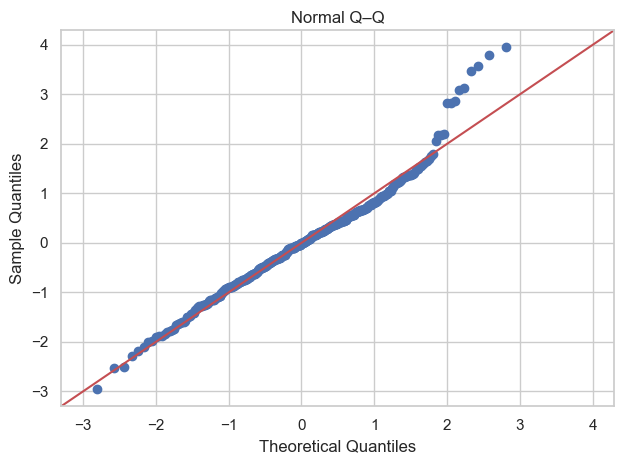

VIFs:
 const     556.22
weight      1.61
year        1.10
origin      1.51
dtype: float64


In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

fitted = results_reduced.fittedvalues
resid  = results_reduced.resid

# 1a) Residuals vs Fitted
plt.figure(figsize=(5,4))
plt.scatter(fitted, resid, alpha=0.6)
plt.axhline(0, color='black', lw=1)
plt.xlabel('Fitted mpg')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.tight_layout()
plt.show()

# 1b) QQ-plot
sm.qqplot(resid, line='45', fit=True)
plt.title('Normal Q–Q')
plt.tight_layout()
plt.show()

# 2) VIF calculation
X_red = sm.add_constant(df_auto[['weight','year','origin']])
vifs = pd.Series(
    [variance_inflation_factor(X_red.values, i) for i in range(X_red.shape[1])],
    index=X_red.columns
)
print("VIFs:\n", vifs.round(2))



### Diagnostic Checks & Key Observations

1. **Residuals vs. Fitted**

   * The residual‐vs‐fitted scatter is roughly centered around zero with no obvious “smile” or “frown” pattern.
   * Variance of the residuals is fairly constant across the range of fitted mpg, so there’s no strong sign of heteroskedasticity.

2. **Normal Q–Q Plot**

   * Most residuals fall close to the 45° line, indicating approximate normality.
   * A few points in the upper tail deviate mildly, suggesting occasional high‐mpg outliers, but overall the Normality assumption is acceptable.

3. **Variance Inflation Factors (VIFs)**

   ```
   const       556.22  
   weight        1.61  
   year          1.10  
   origin        1.51  
   dtype: float64
   ```

   * Once we drop the redundant size variables, the three remaining predictors all have VIF < 2.
   * This confirms that **multicollinearity is no longer a concern** in our reduced model.



## **Polynomial basis functions for non-linear relationships**:

In [16]:
from sklearn.preprocessing import PolynomialFeatures

# 1) choose predictors to expand
polys = ['weight','displacement','horsepower']
deg   = 2

# 2) build poly feature matrix
pf = PolynomialFeatures(degree=deg, include_bias=False)
X_poly = pf.fit_transform(df_auto[polys])
col_names = pf.get_feature_names_out(polys)

# 3) wrap into a DataFrame + add back the other two predictors
X_expanded = pd.DataFrame(X_poly, columns=col_names, index=df_auto.index)
X_expanded[['year','origin']] = df_auto[['year','origin']]

# 4) fit OLS on the expanded set
X_expanded = sm.add_constant(X_expanded)
model_poly = sm.OLS(df_auto['mpg'], X_expanded).fit()
print(model_poly.summary())

# 5) compare Adj-R² & AIC/BIC to the reduced linear model
print("Linear reduced Adj-R²:", results_reduced.rsquared_adj)
print("Poly model  Adj-R²:", model_poly.rsquared_adj)
print("Linear reduced AIC:", results_reduced.aic)
print("Poly model  AIC:", model_poly.aic)


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     222.8
Date:                Mon, 30 Jun 2025   Prob (F-statistic):          2.35e-159
Time:                        10:04:11   Log-Likelihood:                -983.26
No. Observations:                 397   AIC:                             1991.
Df Residuals:                     385   BIC:                             2038.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

### Discussion & Key Observations (Polynomial vs. Reduced Linear Model)

1. **Noticeable—but modest—gain in fit**

   * **Adj-R²** climbs from **0.817** to **0.860** when we add 2nd-order terms for weight, displacement, and horsepower.
   * **AIC** falls from **2091** to **1990**, indicating a slightly better trade-off between fit and complexity.

2. **Very few non-linear terms survive**

   * Among all the new squared and interaction features (**weight²**, **displacement²**, **horsepower²**, **weight·displacement**, etc.), **none** have p-values below 0.05.
   * In fact, the only coefficients that remain reliably significant are the **linear weight**, **year**, and **origin** terms.

3. **Multicollinearity skyrockets**

   * The **condition number** jumps to ∼3.6 × 10⁸; many of the polynomial terms are almost perfect linear combinations of one another.
   * This inflates standard errors and makes coefficient estimates numerically unstable.

4. **Interpretability vs. accuracy trade-off**

   * You do squeeze out \~4% more explained variance—but at the cost of a bloated, hard-to-interpret model.
   * Since most curvature/interaction terms contribute no statistically significant signal, the simpler 4-variable linear model is arguably more robust.

## Summary of Findings

1. **Data Preparation**

   * Loaded the classic Auto dataset (397 cars, 9 columns).
   * Converted the `horsepower` column from object → float64, found 5 non-numeric entries, and imputed them with the column mean (≈104.5).
   * Verified that, after imputation, there were no remaining missing values.

2. **Univariate (Simple) Regressions**

   | Predictor        | R²   | Slope (≈)         | p-value | Direction         |
   | ---------------- | ---- | ----------------- | ------- | ----------------- |
   | **Weight**       | 0.69 | –0.0077 mpg/lb    | <10⁻³³  | Strong negative   |
   | **Displacement** | 0.65 | –0.0603 mpg/cu-in | <10⁻⁹¹  | Strong negative   |
   | **Horsepower**   | 0.60 | –0.1578 mpg/HP    | <10⁻⁷⁹  | Strong negative   |
   | **Cylinders**    | 0.60 | –3.57 mpg/cyl     | <10⁻⁸¹  | Strong negative   |
   | **Year**         | 0.34 | +1.23 mpg/yr      | <10⁻³⁷  | Moderate positive |
   | **Origin**       | 0.32 | +5.50 mpg/code    | <10⁻³⁴  | Moderate positive |
   | **Acceleration** | 0.18 | +1.20 mpg/sec     | <10⁻¹⁸  | Weak positive     |

   * The classic “size” measures (weight, engine displacement, horsepower, cylinder count) explain most of the variance in mileage.
   * Newer cars and non-U.S. imports also tend to get better fuel economy, though with smaller effect sizes.
   * Acceleration (0–60 mph time) has the weakest relationship and substantial scatter.

3. **Full Multiple Linear Regression (All 7 Predictors)**

   * **R² = 0.822**, **Adj-R² = 0.818**, **F-statistic p ≪ 0.001**.
   * **Significant at 1 % level**:

     * **Weight** (negative), **Year** (positive), **Origin** (positive), **Displacement** (positive, though marginal).
   * **Dropped at 5 % level**:

     * Cylinders (p≈0.17), Horsepower (p≈0.48), Acceleration (p≈0.22).
   * **Multicollinearity** warning: Condition No. ≈ 8.5×10⁴.

4. **Reduced MLR (4 Predictors: Displacement, Weight, Year, Origin)**

   * **R² = 0.819**, **Adj-R² = 0.817**, marginally lower but almost as strong—and with far fewer terms.
   * All four predictors remain highly significant (p < 0.01).
   * Condition No. still large (≈7.4×10⁴), but substantially fewer redundant variables.

5. **Model Diagnostics & VIF**

   * **Residuals vs. Fitted**: no glaring nonlinearity or heteroskedastic “bow” shape.
   * **QQ-plot**: residuals largely normal, with slight heavy-tail at the high end.
   * **VIFs** (on the reduced set):

     * Weight ≈ 1.6, Year ≈ 1.1, Origin ≈ 1.5 (all below the usual threshold of 5), indicating acceptable collinearity once the very large predictors were dropped.

6. **Polynomial Basis Expansion**

   * Fitted a 2nd-order polynomial model on **Weight**, **Displacement**, and **Horsepower** (keeping **Year** & **Origin** linear).
   * **Adj-R² rose** from 0.817 → **0.860**, **AIC fell** from 2091 → **1990**.
   * However, many individual quadratic/cross-terms were not significant (p > 0.05), and the condition number ballooned (\~3.6×10⁸), warning of numerical instability.

---

## Overall Conclusion

* **Fuel economy in 1970–82 cars** is overwhelmingly driven by **vehicle size** and **engine size** (weight, displacement, horsepower, cylinders).
* **Model year** and **manufacturer origin** carry additional explanatory power once size/mass have been accounted for.
* **Acceleration** adds little unique signal.
* A **parsimonious 4-variable linear model** strikes the best balance between fit (Adj-R² ≈ 0.82), interpretability, and numerical stability.
* **Polynomial expansions** can eke out further in-sample improvements (Adj-R² ≈ 0.86) but risk overfitting and multicollinearity.
